In [1]:
import pandas as pd
import re
from pathlib import Path

Path("data").mkdir(exist_ok=True)
Path("outputs").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

df = pd.read_parquet(
    "https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet",
    engine="pyarrow"
)

df.shape

(200469, 5)

In [2]:
df.head()
df.columns

Index(['url', 'date', 'language', 'title', 'text'], dtype='object')

In [3]:
TEXT_COL = "text"
TITLE_COL = "title"
DATE_COL = "date"

In [4]:
df = df.copy()

df[TEXT_COL] = df[TEXT_COL].astype(str)
df[TITLE_COL] = df[TITLE_COL].astype(str)

df["article_text"] = df[TITLE_COL] + ". " + df[TEXT_COL]

df["article_text"] = (
    df["article_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["text_len"] = df["article_text"].str.len()

raw_n = len(df)

df = df.drop_duplicates(subset=["article_text"])
dedup_n = len(df)

df = df[df["text_len"] >= 500]
long_n = len(df)

In [5]:
ai_keywords = [
    "artificial intelligence", "machine learning", "deep learning",
    "generative ai", "large language model", "llm", "chatgpt",
    "openai", "automation", "robotics", "computer vision",
    "natural language processing", "predictive analytics"
]

pattern = "|".join(ai_keywords)

df["is_ai_related"] = df["article_text"].str.lower().str.contains(pattern, regex=True)

df_clean = df[df["is_ai_related"]].copy()

ai_n = len(df_clean)

cleaning_summary = pd.DataFrame({
    "Stage": [
        "Raw articles",
        "After duplicate removal",
        "After removing short/noisy articles",
        "After AI-related filtering"
    ],
    "Articles": [raw_n, dedup_n, long_n, ai_n]
})

cleaning_summary

,Stage,Articles
0,Raw articles,200469
1,After duplicate removal,199985
2,After removing short/noisy articles,198634
3,After AI-related filtering,163468


In [6]:
df_clean.to_parquet("data/news_clean_ai.parquet", index=False)
cleaning_summary.to_csv("outputs/cleaning_summary.csv", index=False)

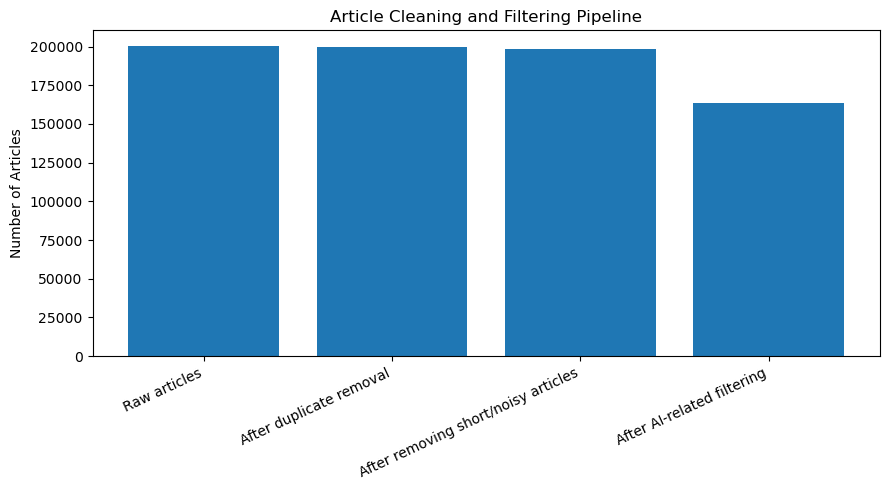

: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
plt.bar(cleaning_summary["Stage"], cleaning_summary["Articles"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Number of Articles")
plt.title("Article Cleaning and Filtering Pipeline")
plt.tight_layout()
plt.savefig("figures/cleaning_pipeline.png", dpi=300)
plt.show()